In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import os 
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# PLSSVD: validation on held-out trials

The primary analysis concerns **new trials from the same participants**. Participant subsamples and new matchings assess sensitivity, not generalisation to unseen participants. Since PLSSVD was chosen using previous results, this is conditional validation of that choice; an independent dataset would strengthen confirmation.

**Open a cluster run:** copy the complete output folder from `plssvd_eval.py` to `out/plssvd_eval`, set `OUTPUT_DIR` below and run all cells. The notebook loads saved CSV/NPZ results and regenerates the plots without the raw data, trial cache, or `src.setting`. Saved run settings take precedence over the analysis defaults below.

To prepare trials and compute a new analysis, use `plssvd_eval.py`; this notebook currently reads completed outputs. The settings below document defaults and do not launch an analysis. For older outputs stored in a modality subfolder, point `OUTPUT_DIR` to that subfolder.


In [5]:
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent))
sys.path.insert(0, str(ROOT.parent / 'LB'))
from plssvd_eval_utils import (ValidationOptions, 
                               prepare_trial_cache, load_trial_cache,
                               validate_plssvd, plot_plssvd_validation, 
                               load_plssvd_results,)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

In [6]:
MEG_KIND = 'full_concatenated'  # full_average, full_concatenated, coverage_average, paired_coverage, random_control
options = ValidationOptions(repeats=5,                 # first: all participants; others: participant subsets + new matching/splits
                            candidates=(1, 2, 3, 5, 10),
                            n_null=199,                # increase for final analysis; minimum tail fraction = 1/(n_null+1)
                            seed=2026,
                            subject_fraction=0.8,
                            split_unit='trial',         # use 'group' with run/stimulus metadata when trials are dependent
                            block_scaling='none')
MEG_RAW_DIR = Path('/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita')
TRIAL_METADATA_CSV = None       
CACHE_DIR = ROOT / 'out' / 'trial_cache'
OUTPUT_DIR = ROOT / 'out' / 'plssvd_eval' 

## Load unaveraged trials
The original MEG `*_source.p` files contain trial averages and cannot support this validation. The exporter uses the `OUT.sources_ERFs` layout from `LB10_extract_data.py` and requires `mat73` when exporting MAT files. iEEG uses the existing epochs and event labels. Cache files are memory-mapped; export requires disk space for all selected trials. Actual MEG and iEEG time vectors must agree; an extra final MEG sample is removed only after checking its time vector.

Optional metadata CSV columns:

| Column | Meaning |
|---|---|
| modality | `ieeg` or `meg` |
| subject | Filename participant identifier |
| condition | Original condition code, e.g. 1 or 2 |
| trial_index | Zero-based trial index **within that condition** |
| split_group | Run or repeated stimulus identity; with `split_unit='group'`, never crosses partitions |
| permutation_block | Acoustic or other exchangeability stratum for condition-label shuffling |

When supplied, the CSV must cover every selected trial. Permutations also respect `split_group` when present. Use group splitting for dependent trials, including repeated stimuli where appropriate. Each condition needs at least eight trials, with at least two in each partition; group splitting may need more. A cache made with different metadata/configuration must be rebuilt in a new directory.

All learned normalisation **in this notebook** is fitted on training data. This cannot undo leakage from upstream across-trial normalisation or data-derived source filters; those must be independent or fitted within folds for a fully strict evaluation.

In [7]:
result = load_plssvd_results(OUTPUT_DIR)
MEG_KIND = result['validation_options']['meg_kind']
print(f"Loaded {MEG_KIND} results from {result['output_dir']}")
display(pd.Series(result['validation_options'], name='Saved validation settings'))
if not result['trial_counts'].empty:
        display(result['trial_counts'])
else:
    display(result['participants'])

Loaded full_concatenated results from /users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/plssvd_eval


repeats                                                               5
candidates                                             [1, 2, 3, 5, 10]
n_null                                                              199
seed                                                               2026
subject_fraction                                                    0.8
split_unit                                                        trial
block_scaling                                                      none
ridge                                                             0.001
max_gram_gib                                                        2.0
meg_kind                                              full_concatenated
ieeg_preprocessing                                fixed multiplier 1000
meg_preprocessing                 zscore of training condition averages
scope                 new trials from selected training participants...
Name: Saved validation settings, dtype: object

,modality,subject,condition,n_trials,n_channels,n_times
0,ieeg,BJH026,1,24,70,1025
1,ieeg,BJH026,2,24,70,1025
2,ieeg,BJH027,1,24,137,1025
3,ieeg,BJH027,2,24,137,1025
4,ieeg,BJH029,1,24,133,1025
...,...,...,...,...,...,...
117,meg,SUBJ_0036,2,23,3559,1025
118,meg,SUBJ_0037,1,20,3559,1025
119,meg,SUBJ_0037,2,25,3559,1025
120,meg,SUBJ_0039,1,24,3559,1025


## Fit, select, and test
Trials are split independently within each modality and participant: approximately 50% train, 20% tune, and two 15% test halves, adjusted to retain at least two trials per condition per partition. No neighbouring time samples are randomly split. Both conditions are stacked along the observation axis to preserve condition differences.

MEG source normalisation is estimated from training condition averages; iEEG retains the fixed ×1000 conversion. Coverage matching is fixed across partitions within a repetition. PLSSVD uses training data only. Component count maximises mean bidirectional **tuning Q² for the original signals**, with fixed training ridge prediction maps; smaller counts win ties. This compares the same target feature space for every count. Test component order and signs remain fixed from training.

Repetition 0 is the predeclared primary full-cohort analysis. Later repetitions change participant subsets, trial splits, and applicable matching realisations. They are overlapping sensitivity analyses, not independent replicates or confidence intervals. Component identities may change across fits; interpret their aggregate metrics, not component-by-component trajectories across repetitions.

In [8]:
display(result['summary'].round(3))
display(result['selection'].query('repeat == 0').round(3))

,repeat,selected_k,n_ieeg,n_meg,train_mean_r,test_mean_r,test_mean_abs_contrast_r,predict_ieeg_q2,predict_meg_q2,ieeg_split_half_r,meg_split_half_r,ieeg_pattern_split_half_r,meg_pattern_split_half_r
0,0,3,30,31,0.906,0.725,0.163,0.055,0.019,0.947,0.763,0.225,0.282
1,1,3,24,25,0.900,0.745,0.240,0.033,0.021,0.830,0.694,0.274,0.346
2,2,3,24,25,0.919,0.660,0.209,0.060,0.021,0.861,0.550,0.303,0.442
3,3,5,24,25,0.888,0.642,0.197,0.057,0.028,0.708,0.559,0.284,0.321
4,4,3,24,25,0.879,0.734,0.141,0.064,0.014,0.962,0.714,0.237,0.488


,repeat,k,tune_predict_ieeg_q2,tune_predict_meg_q2,selection_score
0,0,1,0.003,0.002,0.003
1,0,2,0.024,0.010,0.017
2,0,3,0.032,0.013,0.023
3,0,5,0.025,0.015,0.020
4,0,10,0.014,0.021,0.018


## Held-out correspondence and reliability

- **test_r:** signed Pearson correlation of corresponding fixed PLS scores across condition × time. High held-out correlation supports reproducible temporal correspondence; it can still be driven by tone responses.
- **Q²:** 1 − prediction error / error of predicting the training feature mean. Positive values improve on this baseline; negative values are worse. This is prediction of independently averaged signals, not individual paired trials.
- **contrast_r:** correlation of condition 2 minus condition 1 time courses. Signed values show direction; the aggregate absolute statistic tests association regardless of direction. Inspect contrast RMS too: correlation alone does not establish a substantial modulation.
- **split_half_r:** agreement between independent test-half scores with fixed training weights. Contrast reliability is reported separately.
- **pattern_split_half_r:** agreement of forward regression patterns estimated separately in each test half. These quantify spatial reproducibility conditional on the training axes, not stability of independently refitted PLS weights.

Reliability correlations are raw split-half estimates, without a Spearman–Brown correction or a calibrated noise ceiling. Poor reliability limits interpretation of low cross-modal agreement.

,repeat,component,train_r,test_r,contrast_r,ieeg_split_half_r,meg_split_half_r,ieeg_contrast_split_half_r,meg_contrast_split_half_r,ieeg_pattern_split_half_r,meg_pattern_split_half_r,ieeg_contrast_rms,meg_contrast_rms
0,0,1,0.819,0.769,-0.138,0.977,0.743,-0.236,0.125,0.532,0.702,0.904,7.98


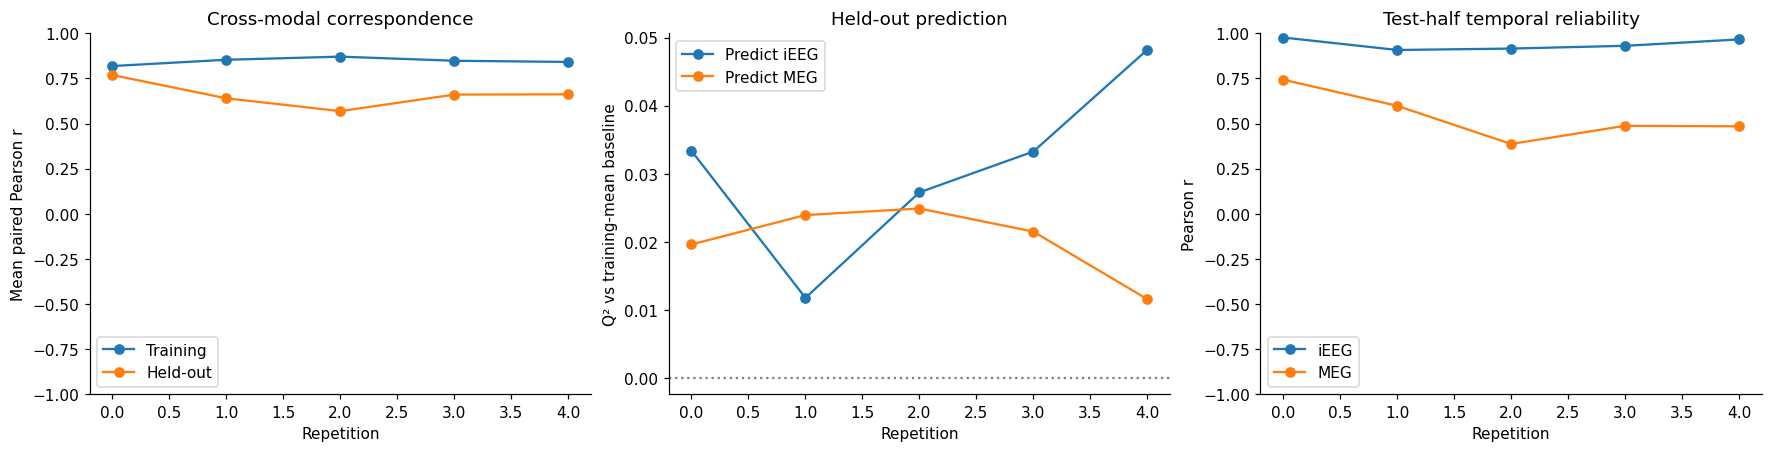

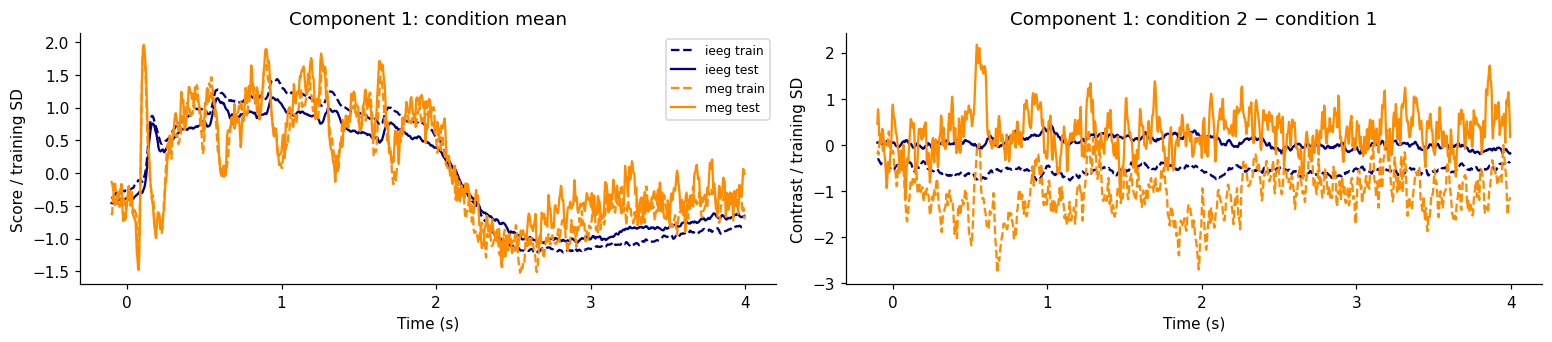

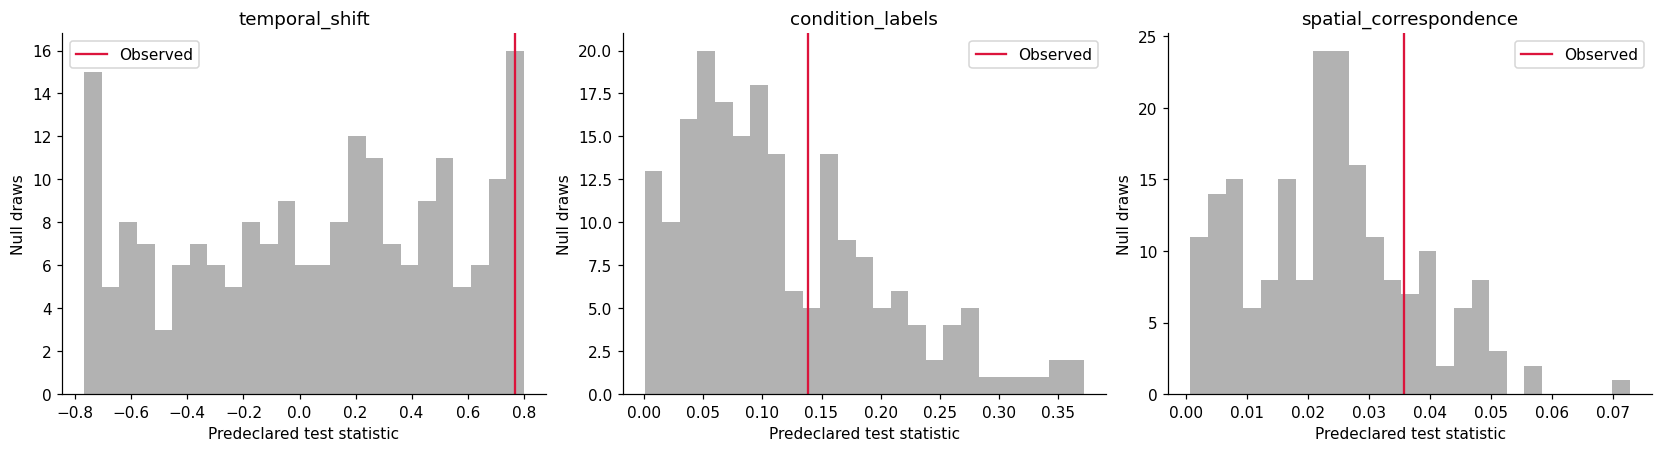

In [6]:
display(result['components'].query('repeat == 0').round(3))
plot_plssvd_validation(result)

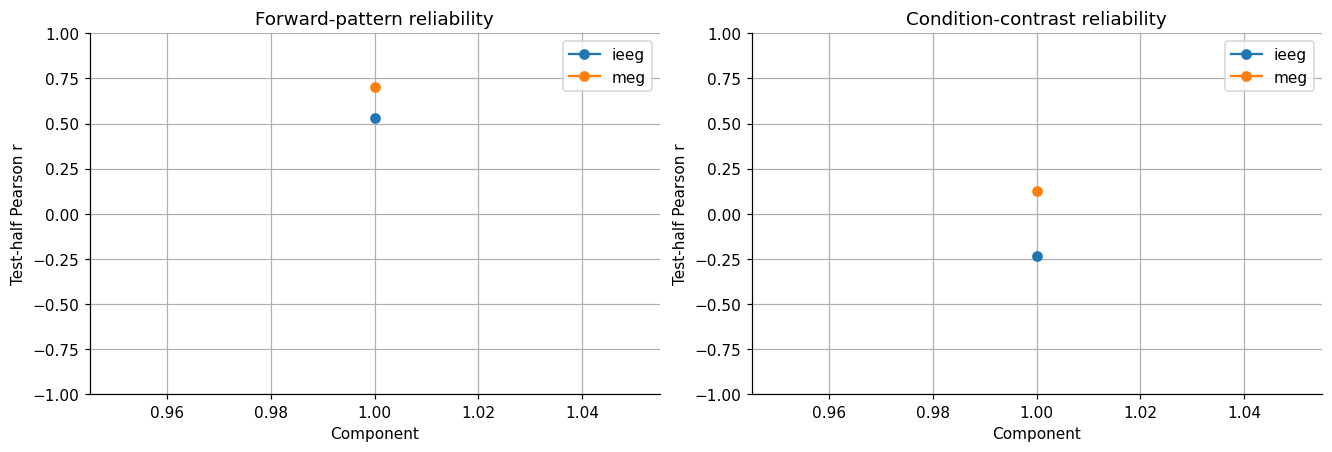

In [7]:
primary = result['components'].query('repeat == 0')
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for modality in ('ieeg', 'meg'):
    axes[0].plot(primary.component, primary[f'{modality}_pattern_split_half_r'], 'o-', label=modality)
    axes[1].plot(primary.component, primary[f'{modality}_contrast_split_half_r'], 'o-', label=modality)
for ax, title in zip(axes, ('Forward-pattern reliability', 'Condition-contrast reliability')):
    ax.set(title=title, xlabel='Component', ylabel='Test-half Pearson r', ylim=(-1, 1))
    ax.legend()
    ax.grid()
plt.show()

## Null models: distinct questions
Nulls are evaluated only for the primary fit, keeping preprocessing, selected component count, and weights fixed. Statistics aggregate the selected components; no test-driven sign flips or component matching are applied.

1. **Temporal shift:** shifts all MEG test scores by the same circular offset within each condition. Tests sensitivity to temporal alignment while preserving circular temporal structure. Epoch-locked responses are nonstationary, so this tail fraction is a **surrogate diagnostic**, not automatically a valid permutation p-value.
2. **Condition labels:** permutes MEG held-out trial labels within participant and exchangeability blocks, preserving counts, then reconstructs projected condition contrasts using the same aggregation. A plus-one permutation tail is interpretable conditionally on exchangeable labels. Blocks containing only one condition cannot be shuffled. Acoustic confounding is not removed by simply labelling this a memory test.
3. **Channel correspondence:** permutes held-out MEG forward-pattern rows within iEEG participant and region (when available). Tests the specified spatial correspondence conditional on the fitted axes. Spatial autocorrelation can violate row exchangeability: treat this as a diagnostic unless those assumptions are justified.

Do not pool tail fractions across sensitivity repetitions. Report all planned tests and account for multiple inferential claims. The mean tone scaffold cancels in the condition difference only to the extent that it is shared across conditions. A recognition-memory claim still requires known condition semantics and adequate control of acoustic/sequence differences.

In [8]:
display(result['null_tests'])
print(f'Results folder: {OUTPUT_DIR}')

,test,observed,tail_fraction,n_null,interpretation,note
0,temporal_shift,0.768798,0.045,199,surrogate / correspondence diagnostic,NaN
1,condition_labels,0.138350,0.350,199,held-out conditional label permutation,NaN
2,spatial_correspondence,0.035686,0.190,199,surrogate / correspondence diagnostic,NaN


Results folder: /users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/plssvd_eval
